# 02 — Compare pipeline output to ground truth

Loads the table `generate_table.ipynb` produced **from the synthetic directory** and
compares it against `data/ground_truth.pkl`.

Three questions:
1. Do the summary statistics recover their true values?
2. Do the LSP peak finders recover the **injected** periods, and is recovery *flat* in
   period (unbiased)?
3. Does the GP recover the injected oscillators?


In [3]:
pwd

'/astro/users/cgwill/TESS_Cluster_Age_ML/GenerateTable_CGW/sytheticdata_generate_compare'

In [9]:
MODULE_DIR

'/astro/users/cgwill/TESS_Cluster_Age_ML/GenerateTable_CGW'

In [11]:
MODULE_DIR+PIPELINE_TABLE

'/astro/users/cgwill/TESS_Cluster_Age_ML/GenerateTable_CGW/data/cluster_table_Aug21_3sectorcombos_synthetic.pkl'

In [12]:
TESS_Cluster_Age_ML/GenerateTable_CGW/data/cluster_table_Aug21_3sectorcombos_synthetic.pkl
TESS_Cluster_Age_ML/GenerateTable_CGW/data/cluster_table_Aug21_3sectorcombos_synthetic.pkl

NameError: name 'TESS_Cluster_Age_ML' is not defined

In [13]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODULE_DIR = os.path.abspath('..')
if MODULE_DIR not in sys.path:
    sys.path.insert(0, MODULE_DIR)

from table_pipeline.table_io import load_from_pickle
from sytheticdata_generate_compare.synth import compare as C

PIPELINE_TABLE = '/data/cluster_table_Aug21_3sectorcombos_synthetic.pkl'   # <- output of generate_table
TRUTH_PATH     = 'data/ground_truth.pkl'

# DATA_DIR = '../data'
# LC_DIR   = '../light_curves_synthetic'
# INTERMEDIATE_TABLE_NAME   = './data/intermediate_table_Aug21_synthetic'
# #OUTPUT   = './data/cluster_table_3sectorcombos_per_cluster_SHOQprior_RNperiodCut'
# OUTPUT   = '../data/cluster_table_Aug21_3sectorcombos_synthetic'



pipe  = load_from_pickle(MODULE_DIR+PIPELINE_TABLE)
truth = pd.read_pickle(TRUTH_PATH)
print(f'pipeline rows={len(pipe)}  clusters={pipe["name"].nunique()}')
print(f'truth rows   ={len(truth)}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[table_io] loaded 246 rows from /astro/users/cgwill/TESS_Cluster_Age_ML/GenerateTable_CGW/data/cluster_table_Aug21_3sectorcombos_synthetic.pkl
pipeline rows=246  clusters=124
truth rows   =348


In [14]:
df = C.join(pipe, truth)
df = C.add_ratio_period(df)          # recompute argmax(P/C) locally for the 3-way test
print(f'joined: {len(df)} rows   with truth: {df["n_osc"].notna().sum()}')

joined: 246 rows   with truth: 246


## 1. Summary statistics

`ratio_median` is pipeline / truth. **An offset in `excess_var` is expected, not a
failure**: truth spans the full ~1143 d baseline while the pipeline sees per-sector
normalised 27 d chunks, and red-noise variance grows as `ln(f_max·T)` — roughly 1.6× at
α = 1. The sinusoid contribution *is* fully recoverable since all periods are in band.

In [15]:
stats = C.stat_comparison(df)
stats

,statistic,n,ratio_median,ratio_p16,ratio_p84,spearman
0,excess_var,246,0.896937,0.411226,1.033052,0.945054
1,sigma_mad,246,0.977344,0.667945,1.085480,0.936824
2,mean_median_offset,246,0.249375,-7.851232,7.278628,0.081753
3,gamma_p,246,0.312784,-8.003086,7.051430,0.103586
4,vn_ratio_gap_aware,246,0.783101,0.332132,1.111452,0.940485
5,stetson_j_gap_aware,246,1.707736,0.988746,2.685205,0.925564
6,intrinsic_std,246,0.947067,0.641242,1.016391,0.945054


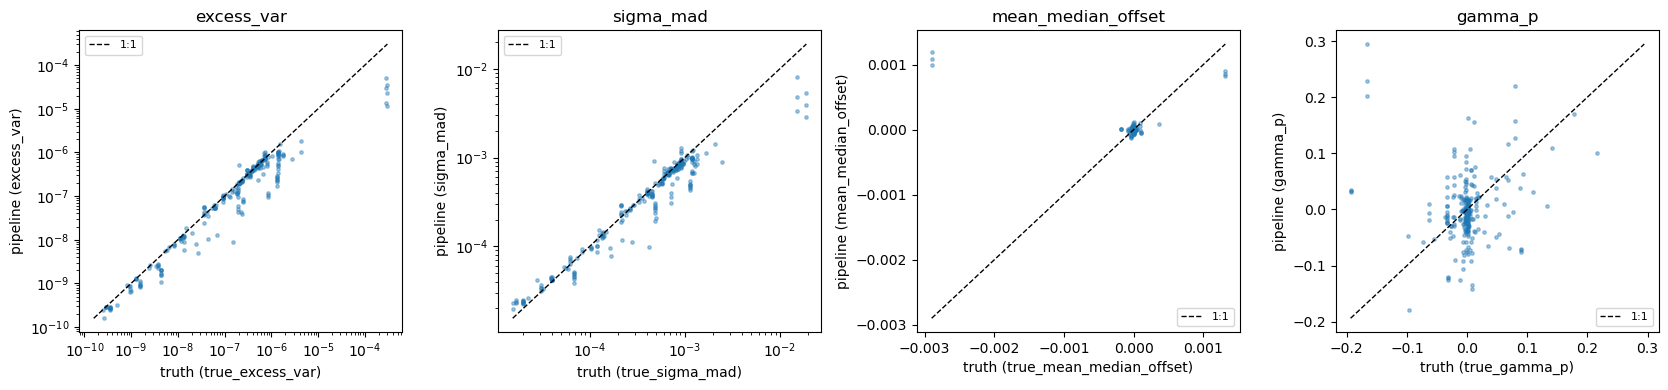

In [16]:
cols = [c for c in ['excess_var','sigma_mad','mean_median_offset','gamma_p'] if c in df]
fig, axs = plt.subplots(1, len(cols), figsize=(4.2*len(cols), 4))
for ax, c in zip(np.atleast_1d(axs), cols):
    t = dict(excess_var='true_excess_var', sigma_mad='true_sigma_mad',
             mean_median_offset='true_mean_median_offset', gamma_p='true_gamma_p')[c]
    x = pd.to_numeric(df[t], errors='coerce'); y = pd.to_numeric(df[c], errors='coerce')
    m = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[m], y[m], s=6, alpha=.4)
    if c in ('excess_var','sigma_mad'):
        ax.set_xscale('log'); ax.set_yscale('log')
    lim = [min(x[m].min(), y[m].min()), max(x[m].max(), y[m].max())]
    ax.plot(lim, lim, 'k--', lw=1, label='1:1')
    ax.set(xlabel=f'truth ({t})', ylabel=f'pipeline ({c})', title=c)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Period recovery — is the finder unbiased?

Recovery fraction binned by **injected** period, for the raw finder, the
continuum-subtracted finder, and the ratio finder (recomputed here since it was removed
from the pipeline).

**A flat row is unbiased** — only then does the recovered period distribution reproduce
the injected one, whatever its shape.

p_lo,0.1,0.4,1.0,2.5
p_hi,0.4,1.0,2.5,9.0
finder,,,,
LSP_peak_period,0.35,0.237,0.317,0.640
LSP_peak_period_diff,0.40,0.237,0.324,0.645
LSP_peak_period_ratio,0.70,0.339,0.417,0.480


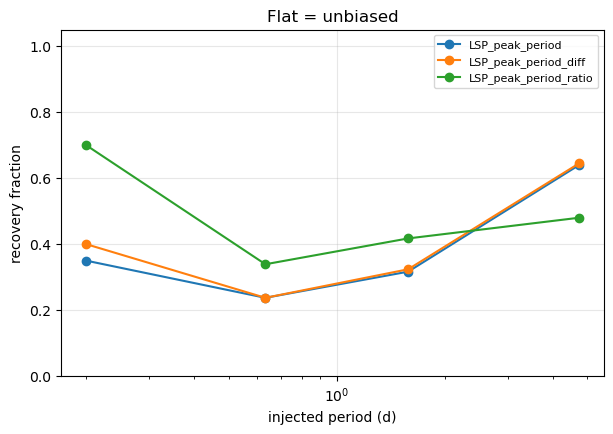

In [17]:
rec = C.period_recovery(df, match='any')
piv = rec.pivot_table(index='finder', columns=['p_lo','p_hi'], values='recovery')
display(piv.round(3))

fig, ax = plt.subplots(figsize=(7,4.5))
for f, g in rec.groupby('finder'):
    ctr = np.sqrt(g['p_lo']*g['p_hi'])
    ax.plot(ctr, g['recovery'], 'o-', label=f)
ax.set(xscale='log', xlabel='injected period (d)', ylabel='recovery fraction',
       ylim=(0,1.05), title='Flat = unbiased')
ax.legend(fontsize=8); ax.grid(alpha=.3); plt.show()

In [18]:
# Same, but requiring the LOUDEST injected oscillator to be the one recovered.
rec_loud = C.period_recovery(df, match='loudest')
rec_loud.pivot_table(index='finder', columns=['p_lo','p_hi'], values='recovery').round(3)

p_lo,0.1,0.4,1.0,2.5
p_hi,0.4,1.0,2.5,9.0
finder,,,,
LSP_peak_period,1.0,0.824,0.857,0.734
LSP_peak_period_diff,1.0,0.824,0.878,0.734
LSP_peak_period_ratio,1.0,0.941,0.898,0.531


## 3. GP recovery

Greedy nearest-match of `gp_periods` to the injected periods in fractional distance.
Each injection is matched at most once, so duplicate components count as spurious.

In [19]:
gp = C.gp_recovery(df, tol=0.10)
print(gp[['n_osc','n_gp','n_matched','n_spurious','n_missed','frac_recovered',
          'median_frac_err']].describe().round(3).to_string())

         n_osc     n_gp  n_matched  n_spurious  n_missed  frac_recovered  median_frac_err
count  246.000  246.000    246.000     246.000   246.000         215.000          174.000
mean     4.573    3.455      1.736       1.720     2.837           0.427            0.010
std      3.284    2.514      1.752       1.484     2.668           0.344            0.015
min      0.000    1.000      0.000       0.000     0.000           0.000            0.000
25%      2.000    1.000      0.000       1.000     0.000           0.125            0.000
50%      4.000    3.000      1.000       1.000     2.000           0.375            0.002
75%      7.750    5.000      3.000       2.000     5.000           0.667            0.014
max     10.000   10.000      8.000       7.000    10.000           1.000            0.080


In [23]:
gp.loc[m,'n_osc']

0       9
1       9
2       9
3       7
4       7
       ..
241    10
242     3
243     2
244     2
245     2
Name: n_osc, Length: 215, dtype: int64

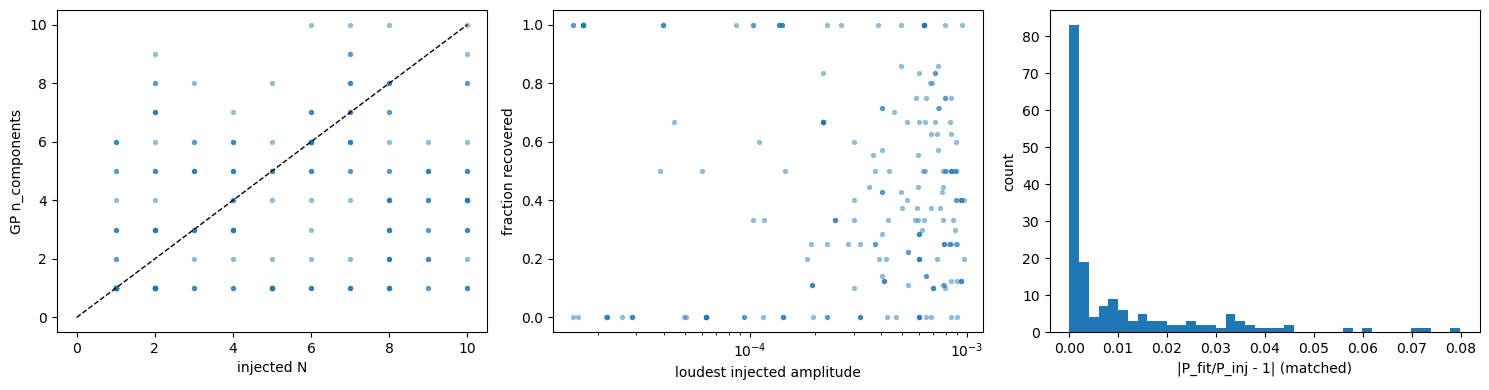

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
m = gp['n_osc'] > 0
axs[0].scatter(gp.loc[m,'n_osc'], gp.loc[m,'n_gp'], s=8, alpha=.4)
lim=[0, max(gp['n_osc'].max(), gp['n_gp'].max())]
axs[0].plot(lim, lim, 'k--', lw=1); axs[0].set(xlabel='injected N', ylabel='GP n_components')
axs[1].scatter(gp.loc[m,'inj_amp_max'], gp.loc[m,'frac_recovered'], s=8, alpha=.4)
axs[1].set(xscale='log', xlabel='loudest injected amplitude', ylabel='fraction recovered')
axs[2].hist(gp.loc[m,'median_frac_err'].dropna(), bins=40)
axs[2].set(xlabel='|P_fit/P_inj - 1| (matched)', ylabel='count')
plt.tight_layout(); plt.show()

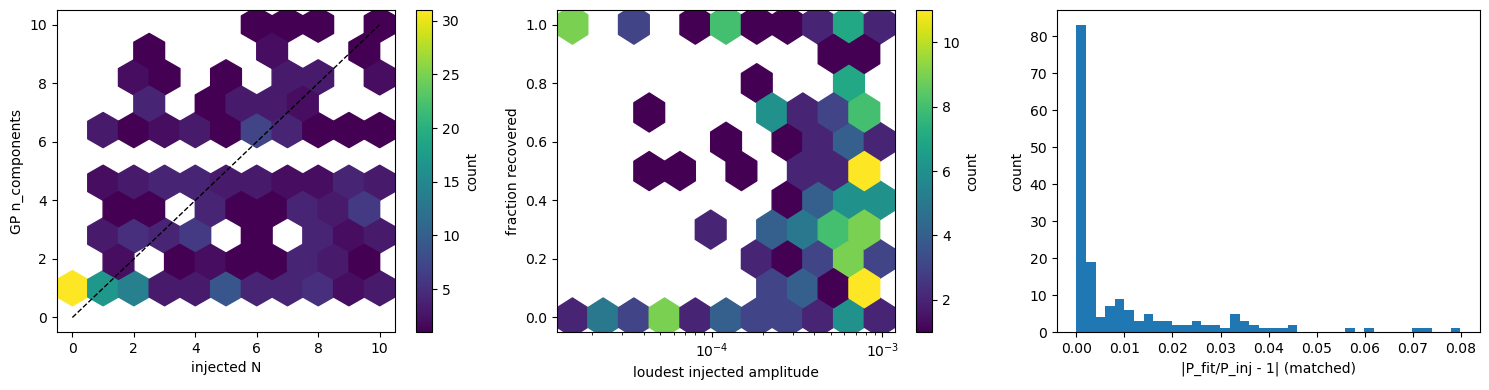

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
m = gp['n_osc'] > -1

# Panel 0: injected N vs GP n_components
hb0 = axs[0].hexbin(gp.loc[m, 'n_osc'], gp.loc[m, 'n_gp'],
                    gridsize=10, mincnt=1, cmap='viridis')
lim = [0, max(gp['n_osc'].max(), gp['n_gp'].max())]
axs[0].plot(lim, lim, 'k--', lw=1)
axs[0].set(xlabel='injected N', ylabel='GP n_components')
fig.colorbar(hb0, ax=axs[0], label='count')

# Panel 1: loudest injected amplitude (log x) vs fraction recovered
hb1 = axs[1].hexbin(gp.loc[m, 'inj_amp_max'], gp.loc[m, 'frac_recovered'],
                    gridsize=10, mincnt=1, cmap='viridis', xscale='log')
axs[1].set(xscale='log', xlabel='loudest injected amplitude',
           ylabel='fraction recovered')
fig.colorbar(hb1, ax=axs[1], label='count')

# Panel 2: histogram (unchanged)
axs[2].hist(gp.loc[m, 'median_frac_err'].dropna(), bins=40)
axs[2].set(xlabel='|P_fit/P_inj - 1| (matched)', ylabel='count')

plt.tight_layout()
plt.show()

---

# 4. Per-oscillator diagnostics — *which* peaks are found, and why

Row-level GP recovery conflates two different things: injections that were **never
detectable**, and injections the GP genuinely **lost**. Amplitudes are drawn log-uniform
spanning well below the noise, so a low raw recovery fraction is expected and says
nothing about the fitter.

Everything below works at the level of the individual injected oscillator, classified by
how far its LSP peak rises above the fitted red-noise continuum **at its own frequency**:

```
ratio = LSP peak power near 1/P     /     C(f) = 10**rn_log10_N * f**(-rn_alpha)
```

An oscillator is *detectable* when `ratio > γ`, the same 1% threshold the peak finder
uses. The question this section answers is whether the misses sit below that line.

In [29]:
osc = C.per_oscillator_table(df)
print(f'{len(osc)} per-oscillator instances  (pipeline rows x injected oscillators)')

s = C.recovery_summary(osc)
for k, v in s.items():
    print(f'  {k:<32} {v:.3f}' if isinstance(v, float) else f'  {k:<32} {v}')

1125 per-oscillator instances  (pipeline rows x injected oscillators)
  n_oscillators                    1125
  recovery_overall                 0.425
  n_detectable                     423
  recovery_detectable              0.957
  recovery_undetectable            0.104
  frac_of_misses_undetectable      0.972
  n_detectable_but_missed          18


## 4.1 The headline: recovery is set by height above the red-noise floor

Left: recovery as a function of `ratio`, with the bin counts annotated. Right: the same
data split on detectability.

**What to look for.** The curve should rise through ~1 near the dashed γ line, and the
right-hand bars should be far apart. If most misses are below threshold, the GP is
behaving — it lost only what was never recoverable.

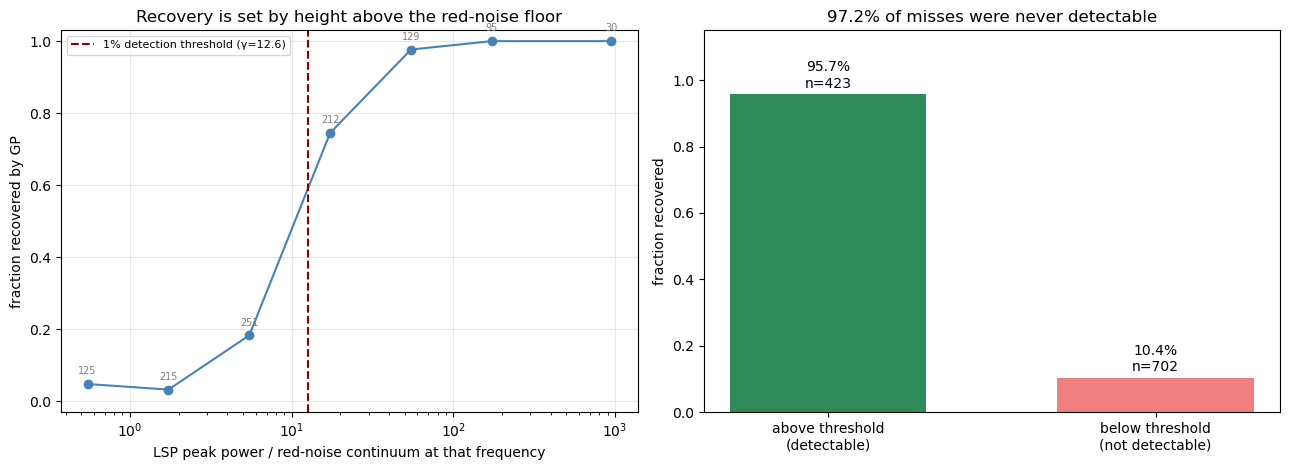

In [30]:
fig = C.plot_recovery_vs_floor(osc); plt.show()

## 4.2 Where the failures live in (period, amplitude)

Split by detectability. In the left panel (detectable), red points are **real failures**
worth investigating. In the right panel (not detectable), red is the expected outcome.

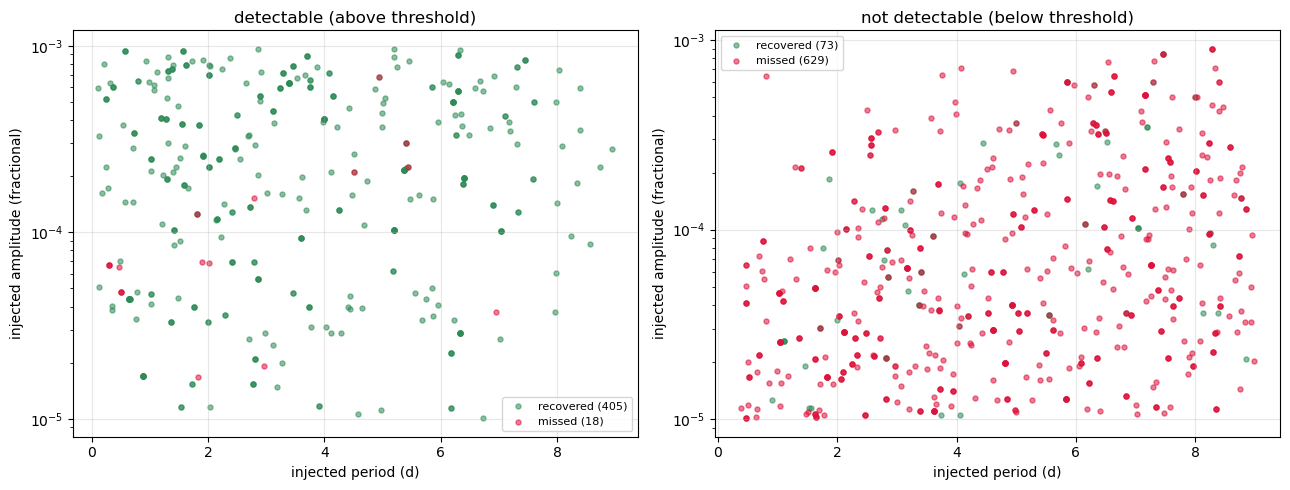

In [31]:
fig = C.plot_period_amplitude(osc); plt.show()

## 4.3 Is there a residual period bias?

Recovery vs period **conditional on the signal being detectable**. Flat means the GP has
no period preference of its own — any decline in the unconditional numbers is then purely
a detectability effect, not a bias in the fitter.

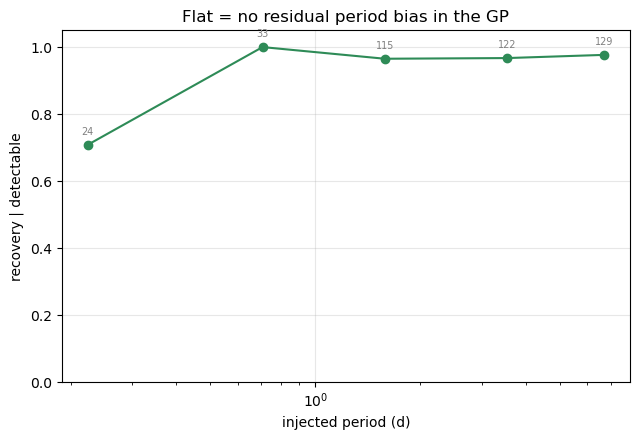

unconditional recovery by period (for contrast):
   0.1-0.5  d  n=  34  recovered=0.500  detectable=0.706
   0.5-1    d  n=  55  recovered=0.618  detectable=0.600
     1-2.5  d  n= 236  recovered=0.525  detectable=0.487
   2.5-5    d  n= 336  recovered=0.435  detectable=0.363
     5-9    d  n= 464  recovered=0.338  detectable=0.278


In [32]:
fig = C.plot_period_bias(osc); plt.show()

print('unconditional recovery by period (for contrast):')
for lo, hi in [(0.1, 0.5), (0.5, 1), (1, 2.5), (2.5, 5), (5, 9)]:
    m = (osc['P'] >= lo) & (osc['P'] < hi)
    if m.sum():
        print(f'  {lo:>4}-{hi:<4} d  n={int(m.sum()):>4}  '
              f'recovered={osc.loc[m, "recovered"].mean():.3f}  '
              f'detectable={osc.loc[m, "signif"].mean():.3f}')

## 4.4 GP component purity — is `Q` a usable filter?

Every fitted GP component is flagged by whether it matches an injected period. Components
matching nothing are spurious.

A pure sinusoid is infinitely coherent, so a component that has locked onto a real signal
is driven to high `Q`, while one absorbing broadband power is not. If the two populations
separate, `Q` is a free purity filter on `gp_sho_Qs`, which is already a stored column.

**Caveat:** the separation is helped by the injections being *pure sinusoids*. Real spot
modulation is quasi-periodic with finite coherence, so expect a softer split on real
data.

850 fitted GP components   (75.9% match an injection)

 Q_cut  frac_kept   purity  completeness
     0   1.000000 0.758824      1.000000
     2   0.867059 0.852103      0.973643
     5   0.838824 0.855540      0.945736
    10   0.807059 0.855685      0.910078
    20   0.752941 0.868750      0.862016
    50   0.576471 0.914286      0.694574
   100   0.480000 0.965686      0.610853
   200   0.416471 0.971751      0.533333
   499   0.335294 0.982456      0.434109


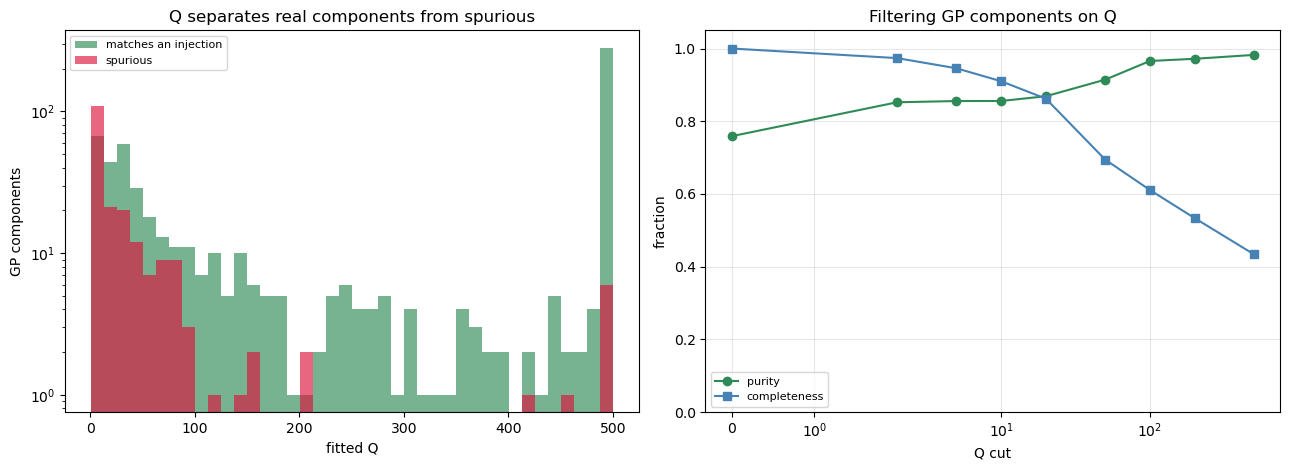

In [33]:
qs = C.gp_component_purity(df)
print(f'{len(qs)} fitted GP components   '
      f'({qs["matches_injected"].mean():.1%} match an injection)')
print()
print(C.purity_curve(qs).to_string(index=False))
fig = C.plot_q_purity(qs); plt.show()

## 4.5 Root cause of the residual failures — continuum contamination

`_fit_red_noise_vaughan` fits **every** frequency bin with no peak masking, so the
injected oscillators bias the fitted continuum steep. A steeper α lifts the detection
threshold at low frequency, which suppresses seeding of genuine peaks — the failure
happens *upstream of the GP*, in the peak finder.

**What to look for.** If `fitted α − injected α` grows with the number of injected
oscillators, that is the mechanism, and it predicts that crowded spectra lose peaks.

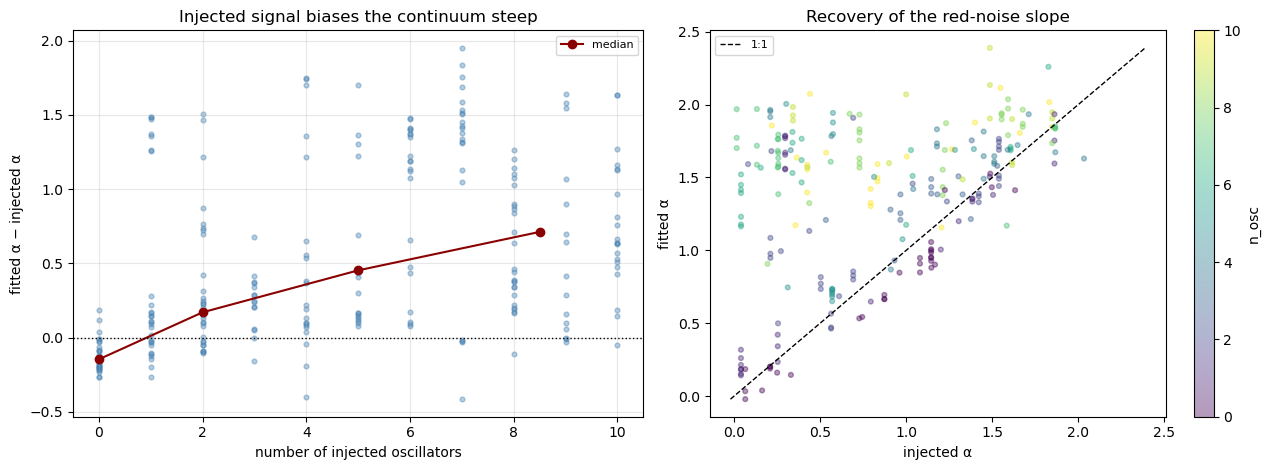

median (fitted α − injected α) by crowding:
  n_osc 0-0: n= 31  median Δα = -0.146
  n_osc 1-3: n= 74  median Δα = +0.170
  n_osc 4-6: n= 58  median Δα = +0.453
  n_osc 7-10: n= 83  median Δα = +0.712


In [40]:
fig = C.plot_alpha_bias(df); plt.show()

a = C.alpha_bias(df)
print('median (fitted α − injected α) by crowding:')
for lo, hi in [(0, 1), (1, 4), (4, 7), (7, 11)]:
    m = (a['n_osc'] >= lo) & (a['n_osc'] < hi)
    if m.sum():
        print(f'  n_osc {lo}-{hi-1}: n={int(m.sum()):>3}  '
              f'median Δα = {a.loc[m, "d_alpha"].median():+.3f}')

### 4.5b The same comparison, using the GP's own red-noise term

§4.5 used the standalone Vaughan power-law fit (`rn_alpha`). The GP fits its **own**
red-noise component, saved as `gp_rn_sigma`, `gp_rn_period`, `gp_rn_Q`.

**These are not the same kind of object.** `gp_rn_Q` is fixed at 1/√2 — the standard
granulation SHO kernel — so the GP's red noise is a *broken* power law: flat below the
break frequency `1/gp_rn_period`, steepening above it. There is no fitted α to plot
directly against the injected one.

So two comparisons instead:

- **Left — amplitude.** `gp_rn_sigma` against the injected red-noise RMS. Directly
  comparable; both are fractional-flux amplitudes.
- **Right — effective slope.** A power law fitted to the GP's SHO PSD over the same band
  the Vaughan fit uses, so the two are measured the same way, with the Vaughan result
  overplotted.

Because the SHO is a broken power law, its effective slope depends on where the break
sits relative to the band:

| break period | 0.2 d | 0.5 d | 1 d | 3 d | 10 d |
|---|---|---|---|---|---|
| α_eff | 0.42 | 1.29 | 2.11 | 3.31 | 3.95 |

saturating at 4 once the break falls below the band — the SHO's asymptotic slope. That
gives a shape-mismatch offset that varies with the fitted break, so **read the trend with
crowding, not the absolute offset.**

*(These values use the corrected `f^-4` PSD. Before the 2026-08-21 fix to `kspace_true`
the analytic PSD fell as `f^-2`, and this table read 0.1 → 2.0 instead.)*

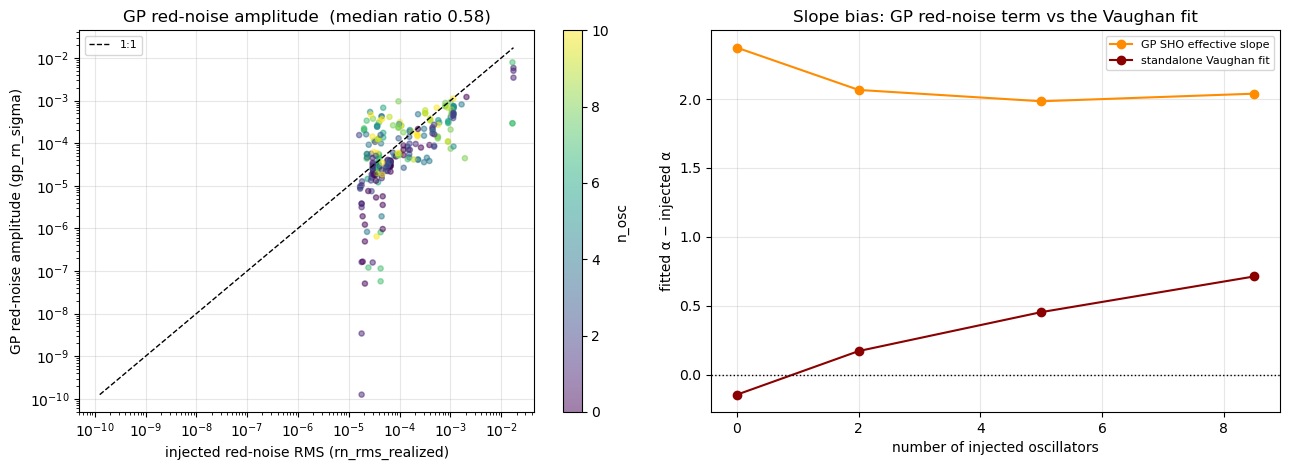

amplitude ratio  gp_rn_sigma / rn_rms_realized :  median=0.58  [p16,p84]=[0.22, 2.25]

n_osc        GP SHO Δα    Vaughan Δα
0-0             +2.373        -0.146
1-3             +2.066        +0.170
4-6             +1.984        +0.453
7-10            +2.039        +0.712

The Vaughan fit degrades monotonically with crowding; the GP's red-noise term
does not. The SHO *signal* components absorb the peaks, leaving the red-noise
term to fit the actual continuum -- protection the unmasked Vaughan fit lacks.
Its own offset is roughly constant and comes from the broken-power-law shape.


In [39]:
fig = C.plot_gp_rn_bias(df); plt.show()

rn = C.gp_rn_bias(df)
print(f"amplitude ratio  gp_rn_sigma / rn_rms_realized :  "
      f"median={rn['amp_ratio'].median():.2f}  "
      f"[p16,p84]=[{rn['amp_ratio'].quantile(.16):.2f}, {rn['amp_ratio'].quantile(.84):.2f}]")
print()
print(f"{'n_osc':<10}{'GP SHO Δα':>12}{'Vaughan Δα':>14}")
for lo, hi in [(0, 1), (1, 4), (4, 7), (7, 11)]:
    m = (rn['n_osc'] >= lo) & (rn['n_osc'] < hi)
    if m.sum():
        print(f"{f'{lo}-{hi-1}':<10}{rn.loc[m,'d_alpha_gp'].median():>+12.3f}"
              f"{rn.loc[m,'d_alpha_vaughan'].median():>+14.3f}")
print()
print("The Vaughan fit degrades monotonically with crowding; the GP's red-noise term")
print("does not. The SHO *signal* components absorb the peaks, leaving the red-noise")
print("term to fit the actual continuum -- protection the unmasked Vaughan fit lacks.")
print("Its own offset is roughly constant and comes from the broken-power-law shape.")

## 4.6 The residual failures, listed

Detectable but missed — the only cases that represent a genuine shortfall. Sorted by how
far above the continuum they were, so the worst offenders come first.

Cross-reference these against the per-cluster figures in
`figs/<run_name>/fig_<CLUSTER>.png` to see the LC, LSP and GP panels together. Compare a
row here with a cluster that recovered everything: the failing ones typically show few
seeded peaks (`seed P=[...]` in the GP PSD panel title) despite visible LSP excursions,
and components pinned at the `Q_min` floor rather than the `Q` cap.

In [35]:
bad = osc[osc['signif'] & ~osc['recovered']].sort_values('ratio', ascending=False)
print(f'{len(bad)} detectable-but-missed, out of {int(osc["signif"].sum())} detectable '
      f'({len(bad)/max(int(osc["signif"].sum()),1):.1%})')
bad[['name', 'n_sectors', 'P', 'A', 'ratio', 'n_osc', 'n_gp']].head(15)

18 detectable-but-missed, out of 423 detectable (4.3%)


,name,n_sectors,P,A,ratio,n_osc,n_gp
583,IC 4996,2,0.295643,0.000067,50.493856,8,2
429,FSR 0336,2,0.498644,0.000048,44.591488,9,2
575,IC 4996,1,0.295643,0.000067,33.525158,8,2
822,NGC 6304,1,2.794025,0.000153,29.894931,8,10
420,FSR 0336,1,0.498644,0.000048,26.632814,9,2
103,BASEL 13,2,4.945275,0.000683,25.441161,8,3
130,BERKELEY 66,2,2.968718,0.000019,23.932506,2,1
386,FSR 0314,2,0.464704,0.000065,22.704038,10,3
1123,VDBERGH-HAGEN 92,2,5.441906,0.000225,22.612309,2,1
567,IC 4996,1,0.295643,0.000067,22.310550,8,2


In [36]:
# Clusters worth eyeballing: best success, and the worst genuine failures.
per = (osc.groupby('name')
          .agg(n_inj=('P', 'size'), n_detectable=('signif', 'sum'),
               n_recovered=('recovered', 'sum'), max_ratio=('ratio', 'max'))
          .reset_index())
per['recovery_of_detectable'] = [
    osc[(osc['name'] == n) & osc['signif']]['recovered'].mean() if d > 0 else np.nan
    for n, d in zip(per['name'], per['n_detectable'])]

print('SUCCESS — many detectable, all recovered:')
print(per[(per['n_detectable'] >= 4) & (per['recovery_of_detectable'] == 1.0)]
      .nlargest(4, 'n_detectable').to_string(index=False))
print('\n"FAILURE" that is actually correct — nothing was above the floor:')
print(per[(per['n_detectable'] == 0) & (per['n_inj'] >= 6)]
      .nlargest(4, 'n_inj').to_string(index=False))
print('\nGENUINE failures — detectable signal missed:')
print(per[per['name'].isin(bad['name'].unique())]
      .nsmallest(5, 'recovery_of_detectable').to_string(index=False))

SUCCESS — many detectable, all recovered:
         name  n_inj  n_detectable  n_recovered   max_ratio  recovery_of_detectable
     SAURER 6     56            30           33  102.287194                     1.0
KRONBERGER 31     49            19           27  158.735792                     1.0
     FSR 1434     21            17           18 1149.747763                     1.0
     NGC 7086     27            15           16   73.252335                     1.0

"FAILURE" that is actually correct — nothing was above the floor:
    name  n_inj  n_detectable  n_recovered  max_ratio  recovery_of_detectable
FSR 0333     18             0            0   7.973082                     NaN
  KING 1     14             0            0   3.279196                     NaN
NGC 6256     10             0            0   5.916804                     NaN

GENUINE failures — detectable signal missed:
            name  n_inj  n_detectable  n_recovered  max_ratio  recovery_of_detectable
     BERKELEY 66      6    